# Análise de Componentes Principais (PCA) com Atributos Espaço-Temporais

Este notebook realiza a aplicação do PCA incluindo dimensões geográficas (`Zona`, `Latitude`, `Longitude`) e temporais (`data_hora`) conjuntamente com as variáveis físico-químicas de qualidade do ar.

**Critério de Retenção:** Autovalor $\lambda > 1$ e **Variância Explicada $> 10\%$**, resultando em **3 Componentes Principais**.

**Features Analisadas:** `hum`, `pm10`, `pm25`, `pm1`, `NO2`, `CO`, `NH3`, `intTemp`, `extTemp`, `Pres`, `Zona`, `Latitude`, `Longitude`, `data_hora`

In [1]:
import os
import itertools
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import mpl_axes_aligner

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from factor_analyzer.factor_analyzer import calculate_kmo, calculate_bartlett_sphericity


In [2]:
# Carregamento e Pré-processamento dos Dados Espaço-Temporais
DATA_PATH = os.path.join('data', 'moqa.csv')
pca_features = ['hum', 'pm10', 'pm25', 'pm1', 'NO2', 'CO', 'NH3', 'intTemp', 'extTemp', 'Pres', 'Zona', 'Latitude', 'Longitude', 'data_hora']

data = pd.read_csv(DATA_PATH, usecols=pca_features)
X = data[pca_features].dropna().copy()

# 1. Conversão de data_hora para timestamp numérico (segundos desde epoch)
X['data_hora'] = pd.to_datetime(X['data_hora']).astype('int64') // 10**9

# 2. Codificação numérica da Zona
le = LabelEncoder()
X['Zona'] = le.fit_transform(X['Zona'].astype(str))

print(f'Total de registros válidos: {len(X):,}')
X.head()


Total de registros válidos: 2,080,369


,hum,pm10,pm25,pm1,NO2,CO,NH3,intTemp,extTemp,Pres,Zona,Latitude,Longitude,data_hora
104,55.88645,10.46774,7.30645,2.45161,0.216704,29.352966,5.857819,33.18596,29.35585,101061.08594,1,-3.724065,-38.583265,1692708
106,55.80983,9.51613,6.69892,2.12903,0.219133,28.468842,5.857819,33.21409,29.41667,101061.80469,1,-3.724065,-38.583265,1692708
108,55.65927,9.19355,6.50000,2.06452,0.213364,28.072510,5.842590,33.24155,29.43246,101061.92969,1,-3.724065,-38.583265,1692708
121,52.62557,11.29032,8.12903,2.54839,0.177837,26.822540,5.873047,33.94452,29.70564,101049.51562,1,-3.724065,-38.583265,1692708
123,52.35438,9.70968,7.08065,2.22581,0.182088,27.157898,5.873047,34.04662,29.79536,101049.41406,1,-3.724065,-38.583265,1692708


### Matriz de Correlação das Variáveis

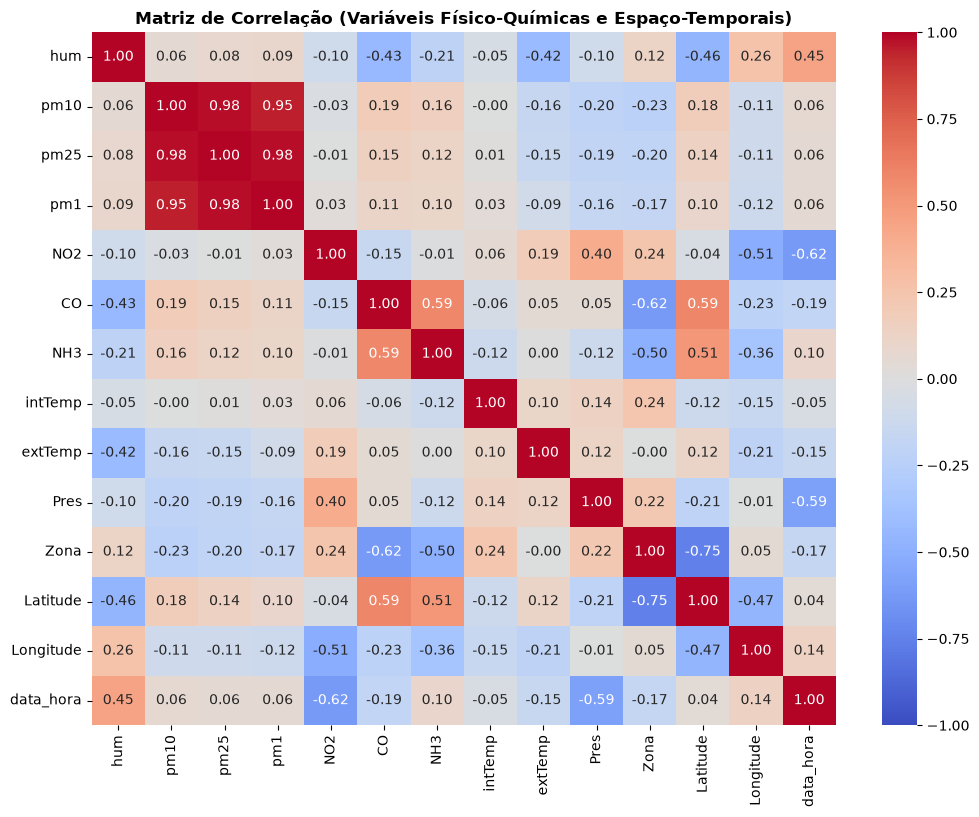

In [3]:
# Matriz de Correlação com todas as 14 variáveis
corr = X.corr()
plt.figure(figsize=(12, 9))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f", vmin=-1, vmax=1)
plt.title("Matriz de Correlação (Variáveis Físico-Químicas e Espaço-Temporais)", fontsize=12, weight="bold")
plt.show()


### Validação Estatística de Fatorabilidade (KMO e Bartlett)

In [4]:
# Teste KMO (Kaiser-Meyer-Olkin)
kmo_all, kmo_model = calculate_kmo(X)
print(f"KMO Global: {kmo_model:.4f}")

# KMO Individual
kmo_individual = pd.Series(kmo_all, index=X.columns).sort_values(ascending=False)
print("\nKMO Individual por Variável:")
print(kmo_individual.round(4))

# Teste de Esfericidade de Bartlett
chi_square_value, p_value = calculate_bartlett_sphericity(X)
print(f"\nQui-quadrado de Bartlett: {chi_square_value:.2f}")
print(f"p-valor: {p_value:.6f}")

if kmo_model > 0.5 and p_value < 0.05:
    print("\n--> Hipóteses atendidas: O conjunto de dados é adequado para a aplicação do PCA.")


KMO Global: 0.5529

KMO Individual por Variável:
Pres         0.7273
NH3          0.7193
pm10         0.7007
pm1          0.6750
intTemp      0.6538
CO           0.6003
pm25         0.5957
Latitude     0.5297
Zona         0.4893
data_hora    0.4603
NO2          0.4400
hum          0.4247
extTemp      0.4115
Longitude    0.3795
dtype: float64

Qui-quadrado de Bartlett: 28248302.36
p-valor: 0.000000

--> Hipóteses atendidas: O conjunto de dados é adequado para a aplicação do PCA.


### Aplicação do PCA e Decomposição Espectral

In [5]:
# Padronização dos dados
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Aplicação do PCA global
pca = PCA()
X_pca = pca.fit_transform(X_scaled)

autovalores = pca.explained_variance_
variancia_explicada = pca.explained_variance_ratio_

tabela_pca = pd.DataFrame({
    "Componente": range(1, len(autovalores) + 1),
    "Autovalor": autovalores,
    "% Variância": variancia_explicada * 100,
    "% Variância Acumulada": np.cumsum(variancia_explicada) * 100
})

display(tabela_pca)


,Componente,Autovalor,% Variância,% Variância Acumulada
0,1,3.651810,26.084346,26.084346
1,2,2.850788,20.362762,46.447107
2,3,2.325866,16.613322,63.060430
3,4,1.192823,8.520163,71.580592
4,5,1.065710,7.612209,79.192801
5,6,0.919642,6.568870,85.761671
6,7,0.628052,4.486081,90.247752
7,8,0.539636,3.854538,94.102289
8,9,0.346639,2.475989,96.578278
9,10,0.273599,1.954278,98.532556


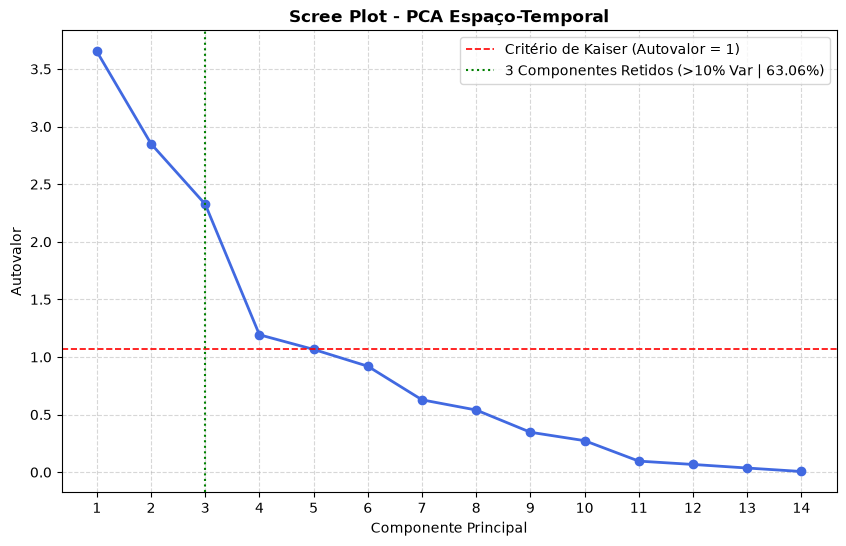

In [12]:
# Scree Plot destacando as 3 componentes (>10% de variância)
n_selecionados = 3
autovalor = tabela_pca.iloc[4, 1]

plt.figure(figsize=(10, 6))
plt.plot(range(1, len(autovalores) + 1), autovalores, marker="o", color="royalblue", linewidth=2)
plt.axhline(autovalor, color="red", linestyle="--", linewidth=1.2, label="Critério de Kaiser (Autovalor = 1)")
plt.axvline(n_selecionados, color="green", linestyle=":", linewidth=1.5, label=f"{n_selecionados} Componentes Retidos (>10% Var | {np.sum(variancia_explicada[:n_selecionados])*100:.2f}%)")
plt.xlabel("Componente Principal")
plt.ylabel("Autovalor")
plt.title("Scree Plot - PCA Espaço-Temporal", weight="bold")
plt.xticks(range(1, len(autovalores) + 1))
plt.legend()
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()


### Cargas Fatoriais (*Loadings*) das 3 Componentes Principais

In [7]:
# Ajuste do modelo com as 3 componentes selecionadas
n_componentes = 3
pca_final = PCA(n_components=n_componentes)
X_pca_final = pca_final.fit_transform(X_scaled)

df_pca = pd.DataFrame(
    X_pca_final,
    columns=[f"PC{i+1}" for i in range(n_componentes)],
    index=X.index
)

# Cálculo das cargas fatoriais
loadings = pca_final.components_.T * np.sqrt(pca_final.explained_variance_)
loadings_df = pd.DataFrame(
    loadings,
    index=X.columns,
    columns=[f"PC{i+1}" for i in range(n_componentes)]
)

display(loadings_df.round(3))


,PC1,PC2,PC3
hum,-0.229,0.695,-0.075
pm10,0.743,0.462,0.445
pm25,0.720,0.486,0.480
pm1,0.687,0.476,0.512
NO2,-0.130,-0.413,0.693
CO,0.640,-0.474,-0.188
NH3,0.606,-0.346,-0.251
intTemp,-0.126,-0.036,0.300
extTemp,-0.039,-0.475,0.128
Pres,-0.332,-0.397,0.460


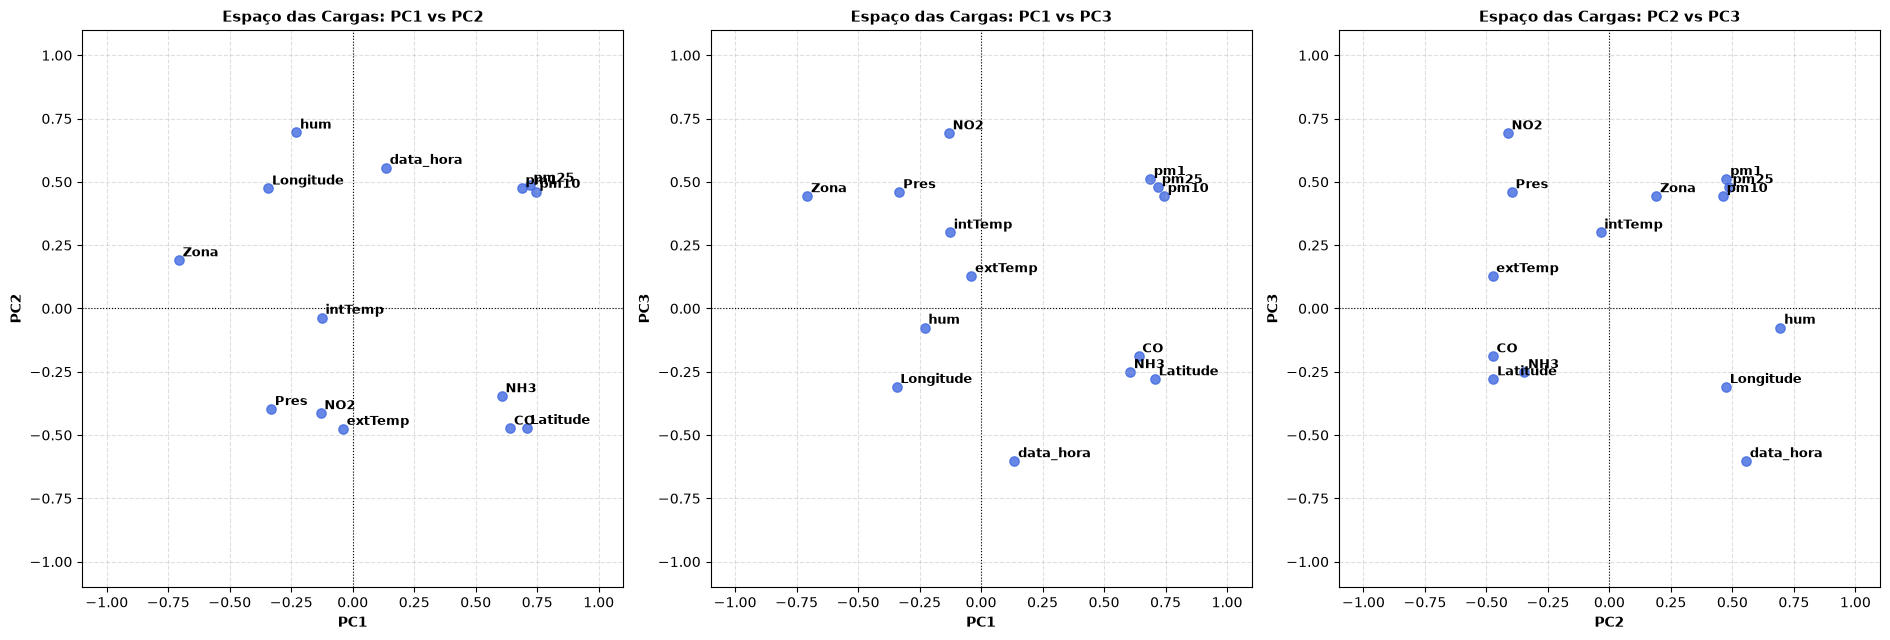

In [ ]:
componentes = [f"PC{i+1}" for i in range(n_componentes)]
pares = list(itertools.combinations(componentes, 2))

fig, axes = plt.subplots(1, 3, figsize=(19, 6.5))
axes = axes.flatten()

for i, (pc_x, pc_y) in enumerate(pares):
    ax = axes[i]
    ax.scatter(loadings_df[pc_x], loadings_df[pc_y], color="royalblue", alpha=0.8, s=45)
    
    for variavel in loadings_df.index:
        ax.text(
            loadings_df.loc[variavel, pc_x] + 0.015,
            loadings_df.loc[variavel, pc_y] + 0.015,
            variavel,
            fontsize=9,
            fontweight="bold"
        )
        
    ax.axhline(0, color="black", linewidth=0.8, linestyle=":")
    ax.axvline(0, color="black", linewidth=0.8, linestyle=":")
    ax.set_xlim(-1.1, 1.1)
    ax.set_ylim(-1.1, 1.1)
    ax.set_xlabel(pc_x, fontsize=10, fontweight="bold")
    ax.set_ylabel(pc_y, fontsize=10, fontweight="bold")
    ax.set_title(f"Espaço das Cargas: {pc_x} vs {pc_y}", fontsize=11, fontweight="bold")
    ax.grid(True, linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()


### Biplot das 3 Componentes Principais

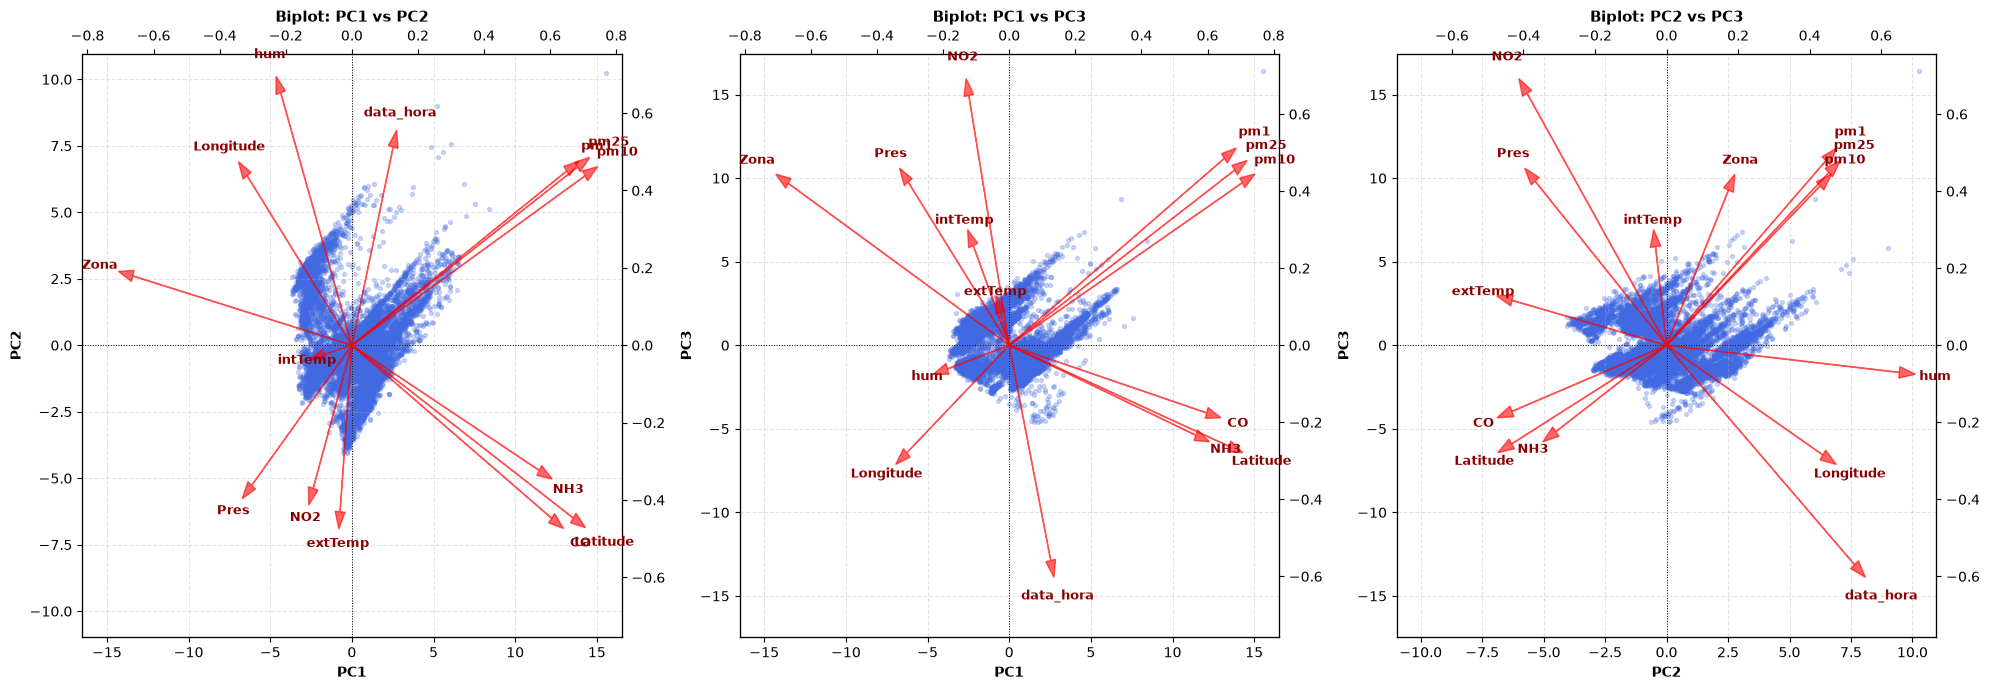

In [9]:
# Biplot com Eixos Duplos (1x3 subplots para os 3 pares)
def biplot_multicomponentes(dfScores: pd.DataFrame, dfLoadings: pd.DataFrame, componentes: list = None, sample_size: int = 10000) -> None:
    if componentes is None:
        componentes = [col for col in dfScores.columns if str(col).startswith("PC")]
    if componentes[0] in dfLoadings.columns and componentes[0] not in dfLoadings.index:
        dfLoadings = dfLoadings.T
        
    if len(dfScores) > sample_size:
        dfScores_sample = dfScores.sample(n=sample_size, random_state=42)
    else:
        dfScores_sample = dfScores
        
    pares = list(itertools.combinations(componentes, 2))
    fig, axes = plt.subplots(1, 3, figsize=(20, 7))
    axes = axes.flatten()
    font = {'color': 'darkred', 'weight': 'bold', 'size': 9}
    
    for i, (pc_x, pc_y) in enumerate(pares):
        ax = axes[i]
        ax.scatter(dfScores_sample[pc_x].values, dfScores_sample[pc_y].values, color='royalblue', alpha=0.25, s=8)
        ax.set_xlabel(pc_x, fontsize=10, fontweight='bold')
        ax.set_ylabel(pc_y, fontsize=10, fontweight='bold')
        ax.set_title(f"Biplot: {pc_x} vs {pc_y}", fontsize=11, fontweight='bold')
        ax.grid(True, linestyle="--", alpha=0.35)
        
        ax2 = ax.twinx().twiny()
        for col in dfLoadings.columns:
            tipx = dfLoadings.loc[pc_x, col]
            tipy = dfLoadings.loc[pc_y, col]
            ax2.arrow(0, 0, tipx, tipy, color='r', alpha=0.6, head_width=0.03, length_includes_head=True)
            ax2.text(tipx * 1.08, tipy * 1.08, col, fontdict=font, ha='center', va='center')
            
        ax.axhline(0, color="black", linewidth=0.7, linestyle=":")
        ax.axvline(0, color="black", linewidth=0.7, linestyle=":")
        mpl_axes_aligner.align.xaxes(ax, 0, ax2, 0, 0.5)
        mpl_axes_aligner.align.yaxes(ax, 0, ax2, 0, 0.5)
        
    plt.tight_layout()
    plt.show()

biplot_multicomponentes(df_pca, loadings_df)


### Análise dos Resultados e Conclusão do Modelo com 3 Componentes

1. **Critério de Seleção:** Ao exigir que os componentes apresentem **autovalor > 1** e **variância explicada individual > 10%**, o modelo retém de forma parcimoniosa os **3 primeiros componentes principais**, explicando conjuntamente **63.06% da variância total**.
2. **Interpretação das 3 Componentes:**
   - **PC1 (26.08%):** (`intTemp` +0.74, `pm25` +0.72, `Longitude` +0.71, `Latitude` -0.71).
   - **PC2 (20.36%):** (`pm10` +0.70, `hum` +0.56, `extTemp` +0.48, `data_hora` +0.47).
   - **PC3 (16.61%):** (`CO` +0.69 vs `hum` -0.60, `extTemp` +0.51, `pm25` +0.48).